In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
grid_agnostic_closed_loop_exp10.py

"""

import os, math, random
from pathlib import Path
from contextlib import nullcontext
import numpy as np
os.environ.setdefault("TORCHINDUCTOR_DISABLE_CUDAGRAPHS", "1")
os.environ.setdefault("TORCHINDUCTOR_CUDAGRAPHS", "0")
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# -------------------------------
# Repro / device
# -------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if DEVICE == "cuda":
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# -------------------------------
# Paths
# -------------------------------
DATA_DIR = Path("/scratch/pp3051/weather")  
SAVE_DIR = Path("./runs_grid_agnostic_closed_loop_exp10_stable")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"[info] device={DEVICE}")
print(f"[info] Loading data from {DATA_DIR.resolve()}")
# -------------------------------
# torch.compile / cudagraph controls
# -------------------------------

USE_TORCH_COMPILE   = False
COMPILE_DYNAMIC     = True
# -------------------------------
# Hyperparameters
# -------------------------------
FREQS = (1, 2, 4, 8)
DIVISORS = (1, 2, 4)

INCLUDE_DX_SCALAR = True
# -------------------------------
# Spectral latent (rFFT) timestepping
# -------------------------------
SPECTRAL_LATENT = True              # << enable "1) spectral latent"
ORTHO_FFT       = True              # ortho rFFT/irFFT for grid-agnostic coefficient scaling
LATENT_M_MAX    = 257               # keep full modes at finest grid (N=512 -> Nf=257)
DZ_CLIP_N       = 5.0               # tanh clip on Δz (real/imag), in "normalized-u FFT units"
LEARNED_DAMPING = False             # disable damping first (prevents low-pass collapse)
DAMP_INIT       = 0.1               # (only used if LEARNED_DAMPING=True)

# direct spectral supervision (keeps phase/amplitude stable)
LAMBDA_Z        = 0.02              # weight on z-coefficient loss at every step
Z_HIGHK_GAMMA   = 2.0               # emphasize high-k in z-loss (0 disables)

# teacher forcing: mix instead of hard Bernoulli switch
TF_MIXING       = True              # z_in = p*z_true + (1-p)*z_pred

BATCH_SIZE = 64 if DEVICE == "cuda" else 32
NUM_WORKERS = 0 if DEVICE != "cuda" else min(8, os.cpu_count() or 1)
JUMP_TRAINING = False               # train true per-step K-rollout, not endpoint jumps
DELTA_MODE = "pow2"      # "uniform" or "pow2"  (pow2 gives "spaced" supervision like 1,2,4,8)
DELTA_MAX = 8            # cap for jump Δ (set to MAX_K)
POW2_DELTAS = (1, 2, 4, 8)  # used if DELTA_MODE="pow2"
JUMP_LOSS_MODE = "endpoint" # "endpoint" (recommended) or "all"
JUMP_SAMPLES_PER_BATCH = 4  # how many random-Δ jump tasks per batch (decouple from curr_K)

# step-based training (steps == batches)
TOTAL_STEPS = 120_000
EVAL_EVERY = 2000
LOG_EVERY = 200
GRAD_CLIP = 1.0

LR_START = 2e-4
LR_MAX   = 2e-3
LR_MIN   = 2e-5
WARMUP_STEPS = 5000

WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.10
# If compounding error is stubborn, try: NORM_TYPE="layer"
NORM_TYPE = "batch"  # "batch" or "layer"

# closed-loop / curriculum
MAX_K = 8
CURR_K = 2
ROLLOUT_ALPHA = 0.20
MIN_STEPS_PER_K = 20_000
PLATEAU_PATIENCE = 3
MIN_IMPROVE = 1e-4

# scheduled sampling (teacher forcing prob)
TF_START = 0.90
TF_END   = 0.00
TF_DECAY_STEPS = 60_000

# noise injected into normalized u inputs during training
INPUT_NOISE_STD = 0.01

# loss mix 
BETA_DU      = 0.50   # weight of du loss vs u loss
LAMBDA_GRAD  = 0.05   # gradient matching
LAMBDA_STATS = 0.001  # mean/std matching
LAMBDA_FFT   = 0.02   # spectrum matching (reduces spectral collapse)

# Δu tanh clip in normalized units (prevents runaway)
DU_CLIP_N = 5.0

# chain detection tolerance
EPS = 0.002


# ============================================
# Utilities
# ============================================
def area_average_downsample_batch(u_hi: np.ndarray, Nx_lo: int):
    Nx_hi = u_hi.shape[-1]
    assert Nx_hi % Nx_lo == 0
    r = Nx_hi // Nx_lo
    new_shape = u_hi.shape[:-1] + (Nx_lo, r)
    return u_hi.reshape(new_shape).mean(axis=-1, dtype=np.float32)

def posenc_from_x(x: np.ndarray, freqs):
    x_min = float(x.min()); x_max = float(x.max())
    x01 = (x - x_min) / max(1e-12, x_max - x_min)
    N = x01.shape[0]
    feats = np.zeros((2 * len(freqs), N), dtype=np.float32)
    for i, f in enumerate(freqs):
        ang = 2 * math.pi * f * x01
        feats[2*i] = np.sin(ang).astype(np.float32)
        feats[2*i+1] = np.cos(ang).astype(np.float32)
    return feats

def rollout_weights(K: int, alpha: float, device: str):
    w = torch.tensor([math.exp(-alpha*k) for k in range(K)], dtype=torch.float32, device=device)
    return w / w.sum().clamp_min(1e-8)

def get_tf_prob(step: int):
    if step >= TF_DECAY_STEPS:
        return TF_END
    frac = step / max(1, TF_DECAY_STEPS)
    return TF_START + (TF_END - TF_START) * frac

def lr_at_step(step: int):
    if step < WARMUP_STEPS:
        return LR_START + (LR_MAX - LR_START) * (step / max(1, WARMUP_STEPS))
    t = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    t = min(max(t, 0.0), 1.0)
    return LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1.0 + math.cos(math.pi * t))

def set_lr(optimizer, lr: float):
    for g in optimizer.param_groups:
        g["lr"] = lr

def weighted_mse(pred, target, width):
    diff2 = (pred - target).square()
    w = width.unsqueeze(1)
    return (diff2 * w).sum() / w.sum().clamp_min(1e-8)

def circular_grad(u):
    return torch.roll(u, shifts=-1, dims=-1) - u

def fft_mag(u):
    # u: [B,1,N] -> magnitude of rfft: [B,1,Nf]
    if ORTHO_FFT:
        F = torch.fft.rfft(u, dim=-1, norm="ortho")
    else:
        F = torch.fft.rfft(u, dim=-1)
    return torch.abs(F)
def _no_autocast():
    # FFT ops are safest in fp32; keep conv net under autocast separately
    if DEVICE == "cuda" and torch.is_autocast_enabled():
        try:
            return torch.amp.autocast("cuda", enabled=False)
        except Exception:
            return torch.cuda.amp.autocast(enabled=False)
    return nullcontext()

def posenc_from_mode(M: int, freqs):
    # mode coordinate in [0,1]
    if M <= 1:
        x = np.zeros((1,), dtype=np.float32)
    else:
        x = np.linspace(0.0, 1.0, M, dtype=np.float32)
    feats = np.zeros((2 * len(freqs), M), dtype=np.float32)
    for i, f in enumerate(freqs):
        ang = 2 * math.pi * f * x
        feats[2*i]   = np.sin(ang).astype(np.float32)
        feats[2*i+1] = np.cos(ang).astype(np.float32)
    return feats

def rfft_trunc(u_n: torch.Tensor, M: int):
    # u_n: [B,1,N] float -> z: [B,M] complex
    if ORTHO_FFT:
        z = torch.fft.rfft(u_n.squeeze(1), dim=-1, norm="ortho")  # [B,Nf] complex
    else:
        z = torch.fft.rfft(u_n.squeeze(1), dim=-1)                 # [B,Nf] complex
    return z[:, :M]

def complex_to_ri(z: torch.Tensor):
    # z: [B,M] complex -> [B,2,M] real
    ri = torch.view_as_real(z)                          # [B,M,2]
    return ri.permute(0, 2, 1).contiguous()            # [B,2,M]

def ri_to_complex(ri: torch.Tensor):
    # ri: [B,2,M] -> [B,M] complex
    return torch.complex(ri[:, 0, :], ri[:, 1, :])

def irfft_from_trunc(z_trunc: torch.Tensor, N: int, Nf: int):
    # z_trunc: [B,M] complex -> u_n: [B,1,N] float
    B, M = z_trunc.shape
    z_full = torch.zeros((B, Nf), device=z_trunc.device, dtype=z_trunc.dtype)
    z_full[:, :M] = z_trunc
    if ORTHO_FFT:
        u = torch.fft.irfft(z_full, n=N, dim=-1, norm="ortho")    # [B,N]
    else:
        u = torch.fft.irfft(z_full, n=N, dim=-1)                  # [B,N]
    return u[:, None, :]
def sample_delta():
    # cap Δ by available future horizon (MAX_K from dataset)
    dmax = min(int(DELTA_MAX), int(MAX_K))
    if dmax <= 1:
        return 1
    if DELTA_MODE == "uniform":
        return random.randint(1, dmax)
    elif DELTA_MODE == "pow2":
        opts = [x for x in POW2_DELTAS if x <= dmax]
        return random.choice(opts) if opts else 1
    else:
        raise ValueError("DELTA_MODE must be 'uniform' or 'pow2'")
@torch.no_grad()
def rmse(pred, target):
    return torch.sqrt(((pred - target) ** 2).mean()).item()


# ============================================
# Data loading + chain building
# ============================================
def load_supervised_pairs(data_dir: Path):
    needed = ["X_train.npy","y_train.npy","X_val.npy","y_val.npy","X_test.npy","y_test.npy"]
    if not all((data_dir/f).exists() for f in needed):
        raise FileNotFoundError("Missing X_*/y_* files in DATA_DIR.")
    Xtr = np.load(data_dir/"X_train.npy").astype(np.float32)
    Ytr = np.load(data_dir/"y_train.npy").astype(np.float32)
    Xva = np.load(data_dir/"X_val.npy").astype(np.float32)
    Yva = np.load(data_dir/"y_val.npy").astype(np.float32)
    Xte = np.load(data_dir/"X_test.npy").astype(np.float32)
    Yte = np.load(data_dir/"y_test.npy").astype(np.float32)
    return Xtr, Ytr, Xva, Yva, Xte, Yte

def try_load_x_t(data_dir: Path):
    x = None; t = None
    for cand in ["ks_spatial_grid.npy", "x.npy", "ks_spatial_grid1.npy"]:
        p = data_dir/cand
        if p.exists():
            x = np.load(p).astype(np.float32)
            break
    for cand in ["ks_time.npy", "t.npy"]:
        p = data_dir/cand
        if p.exists():
            t = np.load(p).astype(np.float32)
            break
    return x, t

def infer_Lx_dt_from_xt(x, t):
    if x is not None:
        Lx = float((x[1]-x[0]) * len(x))
    else:
        Lx = 2 * math.pi
    dt = None
    if t is not None and len(t) >= 2:
        dt = float(t[1]-t[0])
    return Lx, dt

def build_chains_by_adjacency(X_all: np.ndarray, Y_all: np.ndarray, eps: float, cache_path: Path):
    if cache_path.exists():
        obj = np.load(cache_path, allow_pickle=True)
        chains = obj["chains"].tolist()
        print(f"[chains] loaded cache -> {cache_path}")
        return chains

    n = X_all.shape[0]
    next_ok = np.zeros(n-1, dtype=np.bool_)
    chunk = 2048
    for s in range(0, n-1, chunk):
        e = min(n-1, s+chunk)
        diff = np.mean(np.abs(Y_all[s:e] - X_all[s+1:e+1]), axis=1)
        next_ok[s:e] = diff < eps

    match_rate = float(next_ok.mean())
    print(f"[graph] adjacency match rate (Y[i]~X[i+1]) = {match_rate:.4f} with eps={eps}")

    if match_rate < 0.95:
        return None

    breaks = np.where(~next_ok)[0]
    starts = np.concatenate([[0], breaks + 1])
    ends   = np.concatenate([breaks, [n-1]])
    chains = [(int(s), int(e)) for s, e in zip(starts, ends) if e - s + 1 >= 4]

    lens = np.array([e-s+1 for s,e in chains], dtype=np.int32)
    print(f"[chains] count={len(chains)} | mean_len={lens.mean():.1f} | max_len={lens.max()} | min_len={lens.min()}")

    np.savez_compressed(cache_path, chains=np.array(chains, dtype=object))
    print(f"[chains] saved cache -> {cache_path}")
    return chains

def build_splits_from_chains(chains, T_train=0.70, T_val=0.15):
    tr, va, te = [], [], []
    for (s,e) in chains:
        L = e - s + 1
        a = int(math.floor(T_train * L))
        b = int(math.floor((T_train + T_val) * L))
        a = max(a, 4); b = max(b, a+1)
        a = min(a, L-2); b = min(b, L-1)
        tr.append((s, s + a - 1))
        va.append((s + a, s + b - 1))
        te.append((s + b, e))
    return tr, va, te

def make_sample_indices(segments, K_max: int):
    idx = []
    for (s,e) in segments:
        lo = s + 2
        hi = e - K_max
        if hi >= lo:
            idx.extend(list(range(lo, hi+1)))
    return np.array(idx, dtype=np.int64)

def coverage_for_K(segments, K: int):
    total = 0
    ok = 0
    for (s,e) in segments:
        total += max(0, (e - (s+2) + 1))
        ok += max(0, (e - K) - (s+2) + 1)
    return (ok / max(1, total))


# ============================================
# Dataset
# ============================================
class ClosedLoopDataset(Dataset):
    def __init__(self, X_all, indices, Lx, dt, freqs, K_max, divisor, include_dx=True):
        super().__init__()
        self.X = X_all
        self.idx = indices
        self.Lx = float(Lx)
        self.dt = dt
        self.freqs = freqs
        self.K_max = int(K_max)
        self.divisor = int(divisor)
        self.include_dx = bool(include_dx)

        self.N0 = int(X_all.shape[1])
        assert self.N0 % self.divisor == 0
        self.N = self.N0 // self.divisor

        self.dx = self.Lx / self.N
        self.width = np.full(self.N, self.dx, dtype=np.float32)
        x = (np.arange(self.N, dtype=np.float32) + 0.5) * self.dx
        self.pe = posenc_from_x(x, self.freqs).astype(np.float32)

    def __len__(self):
        return int(self.idx.shape[0])

    def _down(self, u):
        if self.divisor == 1:
            return u.astype(np.float32, copy=False)
        return area_average_downsample_batch(u.astype(np.float32, copy=False), self.N)

    def __getitem__(self, j):
        i = int(self.idx[j])
        u_tm2 = self._down(self.X[i-2])
        u_tm1 = self._down(self.X[i-1])
        u_t   = self._down(self.X[i])
        futures = self._down(self.X[i+1:i+1+self.K_max])  # [Kmax,N]

        profiles = np.concatenate([u_tm2[None], u_tm1[None], u_t[None], self.pe], axis=0).astype(np.float32)

        scalars = [self.Lx]
        if self.dt is not None:
            scalars.append(float(self.dt))
        if self.include_dx:
            scalars.append(float(self.dx))
        scalars = np.array(scalars, dtype=np.float32)

        return {
            "profiles_raw": profiles,     # [Cin,N] physical u in first 3
            "future_raw": futures,        # [Kmax,N] physical
            "width": self.width,          # [N]
            "scalars": scalars,           # [S]
        }


# ============================================
# Model
# ============================================
class BatchOrLayerNorm1d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        self.norm_type = norm_type
        if norm_type == "batch":
            self.bn = nn.BatchNorm1d(num_features)
            self.ln = None
        elif norm_type == "layer":
            self.ln = nn.LayerNorm(num_features)
            self.bn = None
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        if self.norm_type == "batch":
            return self.bn(x)
        x_perm = x.permute(0, 2, 1)      # [B,L,C]
        x_norm = self.ln(x_perm)
        return x_norm.permute(0, 2, 1)

class ResidualDilated1D(nn.Module):
    def __init__(self, ch, d, norm_type, dropout_p):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act1  = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout(p=dropout_p)

        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1, dilation=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act2  = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout(p=dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class SpectralLatentStepper1D(nn.Module):
    """
    Operates on truncated rFFT coefficients along mode axis M.
    Input channels typically:
      z_{t-2}(2) + z_{t-1}(2) + z_t(2) + pe_k(2*len(freqs)) + k2(1) = 6 + 2*len(freqs) + 1
    Output:
      dz (2 channels: real/imag)
    """
    def __init__(self, cin_latent, scalar_dim, hidden=96, norm_type="batch", dropout_p=0.1,
                 dz_clip_n=5.0, learned_damping=True, damp_init=2.0):
        super().__init__()
        self.dz_clip_n = float(dz_clip_n)
        self.learned_damping = bool(learned_damping)
        if self.learned_damping:
            # softplus(log_damp) gives c; damping factor is exp(-c*k2)
            self.log_damp = nn.Parameter(torch.tensor(
                float(math.log(math.expm1(damp_init) + 1e-6)), dtype=torch.float32
            ))
        else:
            self.register_buffer("log_damp", torch.tensor(0.0), persistent=False)

        self.stem = nn.Sequential(
            nn.Conv1d(cin_latent, hidden, 3, padding=1, bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )

        # residual dilated stack along mode axis
        self.b1 = ResidualDilated1D(hidden, 1,  norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2,  norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4,  norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8,  norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv1d(hidden + 32, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 2, 1),
        )

    def damp(self, z: torch.Tensor, k2: torch.Tensor):
        # z: complex [B,M], k2: real [1,M]
        if not self.learned_damping:
            return z
        c = torch.nn.functional.softplus(self.log_damp) + 1e-6
        a = torch.exp(-c * k2)  # [1,M]
        return z * a

    def forward(self, profiles_latent, scalars):
        # profiles_latent: [B,Cin_latent,M], scalars: [B,scalar_dim]
        h = self.stem(profiles_latent)
        h = self.b4(self.b3(self.b2(self.b1(h))))
        B, C, M = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 32, M)
        h = torch.cat([h, s], dim=1)
        dz = self.head(h)  # [B,2,M]
        c = self.dz_clip_n
        if c > 0:
            dz = c * torch.tanh(dz / c)
        return dz

class GridAgnostic1D(nn.Module):
    def __init__(self, cin, scalar_dim, hidden=96, norm_type="batch", dropout_p=0.1, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv1d(cin, hidden, 3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )

        self.b1 = ResidualDilated1D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8, norm_type, dropout_p)
        self.b5 = ResidualDilated1D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv1d(hidden + 32, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 1, 1),
        )

    def forward(self, profiles, scalars):
        h = self.stem(profiles)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))

        B, C, L = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 32, L)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)
        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out


# ============================================
# Build chains/splits, loaders, normalization
# ============================================
Xtr, Ytr, Xva, Yva, Xte, Yte = load_supervised_pairs(DATA_DIR)
print(f"[shapes] Xtr {Xtr.shape} | Ytr {Ytr.shape}")
print(f"[shapes] Xva {Xva.shape} | Yva {Yva.shape}")
print(f"[shapes] Xte {Xte.shape} | Yte {Yte.shape}")

X_all = np.concatenate([Xtr, Xva, Xte], axis=0).astype(np.float32, copy=False)
Y_all = np.concatenate([Ytr, Yva, Yte], axis=0).astype(np.float32, copy=False)
print(f"[global] X_all {X_all.shape} Y_all {Y_all.shape}")

x_arr, t_arr = try_load_x_t(DATA_DIR)
Lx, dt = infer_Lx_dt_from_xt(x_arr, t_arr)

cache_path = SAVE_DIR / "chains_cache.npz"
print(f"[graph] using eps={EPS}")

chains = build_chains_by_adjacency(X_all, Y_all, eps=EPS, cache_path=cache_path)
if chains is None:
    raise RuntimeError(
        "Data is not stored sequentially enough for adjacency-based chain building.\n"
        "Re-generate data with shuffle disabled / trajectory-major layout."
    )

tr_segs, va_segs, te_segs = build_splits_from_chains(chains, T_train=0.70, T_val=0.15)
tr_idx = make_sample_indices(tr_segs, K_max=MAX_K)
va_idx = make_sample_indices(va_segs, K_max=MAX_K)
te_idx = make_sample_indices(te_segs, K_max=MAX_K)

print(f"[split] train samples={len(tr_idx)} | val samples={len(va_idx)} | test samples={len(te_idx)}")
print("[coverage] " + " ".join([f"K>={k}:{coverage_for_K(va_segs,k):.3f}" for k in range(1, MAX_K+1)]))

def compute_norms_per_divisor(X_all, tr_segs, divisors):
    norms = {}
    N0 = X_all.shape[1]
    for d in divisors:
        N = N0 // d
        frames = []
        for (s,e) in tr_segs:
            frames.append(X_all[s:e+1])
        U = np.concatenate(frames, axis=0).astype(np.float32, copy=False)
        if d != 1:
            U = area_average_downsample_batch(U, N)
        u_mean = float(U.mean())
        u_std  = float(U.std() + 1e-8)
        DU = U[1:] - U[:-1]
        du_mean = float(DU.mean())
        du_std  = float(DU.std() + 1e-8)
        norms[d] = (u_mean, u_std, du_mean, du_std)
        print(f"[norm d={d}] u_mean={u_mean:.4g} u_std={u_std:.4g} | du_mean={du_mean:.4g} du_std={du_std:.4g}")
    return norms

norms = compute_norms_per_divisor(X_all, tr_segs, DIVISORS)

Cin = 3 + 2 * len(FREQS)
Sdim = 1 + (1 if dt is not None else 0) + (1 if INCLUDE_DX_SCALAR else 0)
print(f"[model] Cin={Cin} Sdim={Sdim}")

def make_loader(indices, divisor, shuffle, batch_size):
    ds = ClosedLoopDataset(
        X_all, indices, Lx=Lx, dt=dt, freqs=FREQS, K_max=MAX_K,
        divisor=divisor, include_dx=INCLUDE_DX_SCALAR
    )
    dl = DataLoader(
        ds,
        batch_size=min(batch_size, len(ds)) if len(ds) > 0 else batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        drop_last=shuffle,
        persistent_workers=(NUM_WORKERS > 0),
    )
    tag = "train" if shuffle else "val/test"
    print(f"[data] {tag} divisor={divisor} N={ds.N} samples={len(ds)} batch={dl.batch_size} batches={len(dl)}")
    return dl

train_loaders = {d: make_loader(tr_idx, d, shuffle=True,  batch_size=BATCH_SIZE) for d in DIVISORS}
val_loaders   = {d: make_loader(va_idx, d, shuffle=False, batch_size=BATCH_SIZE) for d in DIVISORS}
test_loaders  = {d: make_loader(te_idx, d, shuffle=False, batch_size=BATCH_SIZE) for d in DIVISORS}

# ============================================
# Build model/optimizer
# ============================================
spectral_cache = {}
if SPECTRAL_LATENT:
    for d, dl in train_loaders.items():
        N = int(dl.dataset.N)
        Nf = N // 2 + 1
        M = int(min(LATENT_M_MAX, Nf))
        pe_k = torch.from_numpy(posenc_from_mode(M, FREQS)).to(DEVICE)         # [Cpe,M]
        if M <= 1:
            k2 = torch.zeros((1, M), dtype=torch.float32, device=DEVICE)
        else:
            # physical wavenumber: k = 2π m / Lx (consistent units across grids)
            m  = torch.arange(M, device=DEVICE, dtype=torch.float32)          # 0..M-1
            k  = (2.0 * math.pi / float(Lx)) * m
            k2 = (k * k)[None, :]                                             # [1,M]
        spectral_cache[d] = {"N": N, "Nf": Nf, "M": M, "pe_k": pe_k, "k2": k2}
        print(f"[spectral] divisor={d} N={N} Nf={Nf} M={M} pe_k={tuple(pe_k.shape)}")

if SPECTRAL_LATENT:
    Cin_latent = 6 + (2 * len(FREQS)) + 1  # z_tm2(2)+z_tm1(2)+z_t(2)+pe_k+ k2
    print(f"[model] spectral latent Cin_latent={Cin_latent} (LATENT_M_MAX={LATENT_M_MAX})")
    model = SpectralLatentStepper1D(
        cin_latent=Cin_latent, scalar_dim=Sdim, hidden=96,
        norm_type=NORM_TYPE, dropout_p=DROPOUT_P,
        dz_clip_n=DZ_CLIP_N,
        learned_damping=LEARNED_DAMPING,
        damp_init=DAMP_INIT,
    ).to(DEVICE)
else:
    model = GridAgnostic1D(
        cin=Cin, scalar_dim=Sdim, hidden=96,
        norm_type=NORM_TYPE, dropout_p=DROPOUT_P,
        du_clip_n=DU_CLIP_N
    ).to(DEVICE)

if USE_TORCH_COMPILE:
    # If you flip this to True, keep cudagraphs disabled via env vars above.
    try:
        model = torch.compile(
            model,
            mode="default",          # reduce-overhead can be more aggressive about cudagraphs
            dynamic=COMPILE_DYNAMIC,
        )
        print("[optimize] torch.compile enabled (cudagraphs disabled via env)")
    except Exception as e:
        print(f"[optimize] torch.compile failed, running eager: {e}")
else:
    print("[optimize] running eager (torch.compile OFF to avoid cudagraph OOM)")

opt = torch.optim.AdamW(model.parameters(), lr=LR_START, weight_decay=WEIGHT_DECAY, fused=(DEVICE=="cuda"))

use_amp = (DEVICE == "cuda")
if use_amp:
    try:
        scaler = torch.amp.GradScaler('cuda', enabled=True)
        autocast = lambda: torch.amp.autocast('cuda', dtype=torch.float16, enabled=True)
    except Exception:
        scaler = torch.cuda.amp.GradScaler(enabled=True)
        autocast = lambda: torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)
else:
    scaler = None
    autocast = None


# ============================================
# Closed-loop loss with scheduled sampling
# ============================================
def closed_loop_loss_spectral(batch, curr_K: int, divisor: int, global_step: int):
    
    # physical norms (used for encode/decode)
    u_mean, u_std, _, _ = norms[divisor]

    profiles_raw = batch["profiles_raw"].to(DEVICE)               # [B,Cin_phys,N]
    future_raw   = batch["future_raw"].to(DEVICE)                 # [B,Kmax,N]
    width        = batch["width"].to(DEVICE)                      # [B,N]
    scalars      = batch["scalars"].to(DEVICE)                    # [B,S]

    u_tm2 = profiles_raw[:, 0:1, :]
    u_tm1 = profiles_raw[:, 1:2, :]
    u_t   = profiles_raw[:, 2:3, :]

    p_tf = get_tf_prob(global_step)
    cache = spectral_cache[divisor]
    N  = int(cache["N"])
    Nf = int(cache["Nf"])
    M  = int(cache["M"])
    pe_k = cache["pe_k"][None, :, :].expand(u_t.shape[0], -1, -1) # [B,Cpe,M]
    k2   = cache["k2"]                                            # [1,M]
    k2ch = k2[:, None, :].expand(u_t.shape[0], 1, M)              # [B,1,M]
    # optional high-k weighting for z loss
    if (Z_HIGHK_GAMMA > 0) and (M > 1):
        kk = torch.arange(M, device=DEVICE, dtype=torch.float32) / float(M - 1)
        wz = (1.0 + float(Z_HIGHK_GAMMA) * (kk * kk))[None, None, :]  # [1,1,M]
    else:
        wz = None

    def spectral_z_loss(z_pred: torch.Tensor, u_true_phys: torch.Tensor):
        # u_true_phys: [B,1,N] physical
        if LAMBDA_Z <= 0:
            return torch.zeros((), device=DEVICE)
        with _no_autocast():
            z_true = rfft_trunc((((u_true_phys - u_mean) / u_std).float()), M)  # [B,M] complex
        ri_p = complex_to_ri(z_pred)  # [B,2,M]
        ri_t = complex_to_ri(z_true)  # [B,2,M]
        diff2 = (ri_p - ri_t).square()
        if wz is not None:
            diff2 = diff2 * wz
        return diff2.mean()
    # helper: make latent profiles
    def make_profiles(z_tm2, z_tm1, z_t):
        ri = torch.cat([complex_to_ri(z_tm2), complex_to_ri(z_tm1), complex_to_ri(z_t)], dim=1)  # [B,6,M]
        return torch.cat([ri, pe_k, k2ch], dim=1)                                                 # [B,Cin_latent,M]

    # encode initial latent history from normalized u
    with _no_autocast():
        u_tm2_n = ((u_tm2 - u_mean) / u_std).float()
        u_tm1_n = ((u_tm1 - u_mean) / u_std).float()
        u_t_n   = ((u_t   - u_mean) / u_std).float()
        z_tm2 = rfft_trunc(u_tm2_n, M)
        z_tm1 = rfft_trunc(u_tm1_n, M)
        z_tz  = rfft_trunc(u_t_n,   M)

    # --------------------------------------------
    # Jump training in latent: z(t) -> z(t+Δ), decode only for loss
    # --------------------------------------------
    if JUMP_TRAINING:
        total = torch.zeros((), device=DEVICE)
        w_each = 1.0 / max(1, int(JUMP_SAMPLES_PER_BATCH))

        u_start = u_t  # physical start for du_total losses

        for _ in range(int(JUMP_SAMPLES_PER_BATCH)):
            delta = sample_delta()
            z_tm2_c, z_tm1_c, z_t_c = z_tm2, z_tm1, z_tz
            z_pred_last = None

            for j in range(delta):
                prof_lat = make_profiles(z_tm2_c, z_tm1_c, z_t_c)
                dz_ri = model(prof_lat, scalars)                  # [B,2,M]
                dz = ri_to_complex(dz_ri)
                z_next = model.damp(z_t_c, k2) + dz
                z_pred_last = z_next

                # scheduled sampling in latent: choose next input z from truth or prediction
                with _no_autocast():
                    u_true_step = future_raw[:, j:j+1, :]
                    u_true_n = ((u_true_step - u_mean) / u_std).float()
                    z_true = rfft_trunc(u_true_n, M)

                if model.training and p_tf > 0:
                    z_in = (p_tf * z_true + (1.0 - p_tf) * z_next) if TF_MIXING else (z_true if (random.random() < p_tf) else z_next)
                else:
                    z_in = z_next

                z_tm2_c, z_tm1_c, z_t_c = z_tm1_c, z_t_c, z_in

            if z_pred_last is None:
                raise RuntimeError("z_pred_last is None (delta should be >= 1).")

            # decode endpoint
            with _no_autocast():
                u_pred_end_n = irfft_from_trunc(z_pred_last, N=N, Nf=Nf)
                u_pred_end = u_pred_end_n * u_std + u_mean

                u_true_end = future_raw[:, delta-1:delta, :]

            loss_u  = weighted_mse(u_pred_end, u_true_end, width)
            du_pred_tot = u_pred_end - u_start
            du_true_tot = u_true_end - u_start
            loss_du = weighted_mse(du_pred_tot, du_true_tot, width)
            loss_g  = weighted_mse(circular_grad(u_pred_end), circular_grad(u_true_end), width) if LAMBDA_GRAD > 0 else 0.0

            if LAMBDA_STATS > 0:
                mu_p = u_pred_end.mean(dim=-1); mu_t = u_true_end.mean(dim=-1)
                sig_p = u_pred_end.std(dim=-1); sig_t = u_true_end.std(dim=-1)
                loss_stats = (mu_p - mu_t).pow(2).mean() + (sig_p - sig_t).pow(2).mean()
            else:
                loss_stats = 0.0

            if LAMBDA_FFT > 0:
                mp = fft_mag(u_pred_end)
                mt = fft_mag(u_true_end)
                nf = mp.shape[-1]
                wfreq = torch.linspace(0.5, 1.5, nf, device=mp.device)[None, None, :]
                loss_fft = ((mp - mt).square() * wfreq).mean()
            else:
                loss_fft = 0.0

            jump_loss = (1.0 - BETA_DU) * loss_u + BETA_DU * loss_du
            jump_loss = jump_loss + LAMBDA_GRAD * loss_g + LAMBDA_STATS * loss_stats + LAMBDA_FFT * loss_fft
            if LAMBDA_Z > 0:
                # spectral supervision at endpoint (only used if you re-enable JUMP_TRAINING)
                jump_loss = jump_loss + float(LAMBDA_Z) * spectral_z_loss(z_pred_last, u_true_end)
            total = total + w_each * jump_loss

        return total

    # --------------------------------------------
    # Autoregressive K-step latent training (decode per-step for loss)
    # --------------------------------------------
    W = rollout_weights(curr_K, ROLLOUT_ALPHA, DEVICE)
    total = 0.0
    z_tm2_c, z_tm1_c, z_t_c = z_tm2, z_tm1, z_tz
    u_t0 = u_t

    for k in range(curr_K):
        prof_lat = make_profiles(z_tm2_c, z_tm1_c, z_t_c)
        dz_ri = model(prof_lat, scalars)
        dz = ri_to_complex(dz_ri)
        z_next = model.damp(z_t_c, k2) + dz

        with _no_autocast():
            u_pred_n = irfft_from_trunc(z_next, N=N, Nf=Nf)
            u_pred = u_pred_n * u_std + u_mean
            u_true = future_raw[:, k:k+1, :]

        loss_u  = weighted_mse(u_pred, u_true, width)
        du_pred = u_pred - u_t0
        du_true = u_true - u_t0
        loss_du = weighted_mse(du_pred, du_true, width)
        loss_g  = weighted_mse(circular_grad(u_pred), circular_grad(u_true), width) if LAMBDA_GRAD > 0 else 0.0

        if LAMBDA_STATS > 0:
            mu_p = u_pred.mean(dim=-1); mu_t = u_true.mean(dim=-1)
            sig_p = u_pred.std(dim=-1); sig_t = u_true.std(dim=-1)
            loss_stats = (mu_p - mu_t).pow(2).mean() + (sig_p - sig_t).pow(2).mean()
        else:
            loss_stats = 0.0

        if LAMBDA_FFT > 0:
            mp = fft_mag(u_pred)
            mt = fft_mag(u_true)
            nf = mp.shape[-1]
            wfreq = torch.linspace(0.5, 1.5, nf, device=mp.device)[None, None, :]
            loss_fft = ((mp - mt).square() * wfreq).mean()
        else:
            loss_fft = 0.0

        step_loss = (1.0 - BETA_DU) * loss_u + BETA_DU * loss_du
        step_loss = step_loss + LAMBDA_GRAD * loss_g + LAMBDA_STATS * loss_stats + LAMBDA_FFT * loss_fft
        if LAMBDA_Z > 0:
            step_loss = step_loss + float(LAMBDA_Z) * spectral_z_loss(z_next, u_true)
        total = total + W[k] * step_loss

        # scheduled sampling in latent
        with _no_autocast():
            u_true_step = future_raw[:, k:k+1, :]
            u_true_n = ((u_true_step - u_mean) / u_std).float()
            z_true = rfft_trunc(u_true_n, M)
        if model.training and p_tf > 0:
            z_in = (p_tf * z_true + (1.0 - p_tf) * z_next) if TF_MIXING else (z_true if (random.random() < p_tf) else z_next)
        else:
            z_in = z_next

        z_tm2_c, z_tm1_c, z_t_c = z_tm1_c, z_t_c, z_in

    return total
def closed_loop_loss(batch, curr_K: int, divisor: int, global_step: int):
    if SPECTRAL_LATENT:
        return closed_loop_loss_spectral(batch, curr_K=curr_K, divisor=divisor, global_step=global_step)
    u_mean, u_std, du_mean, du_std = norms[divisor]

    profiles_raw = batch["profiles_raw"].to(DEVICE)               # [B,Cin,N]
    future_raw   = batch["future_raw"].to(DEVICE)                 # [B,Kmax,N]
    width        = batch["width"].to(DEVICE)                      # [B,N]
    scalars      = batch["scalars"].to(DEVICE)                    # [B,S]

    u_tm2 = profiles_raw[:, 0:1, :]
    u_tm1 = profiles_raw[:, 1:2, :]
    u_t   = profiles_raw[:, 2:3, :]
    pe    = profiles_raw[:, 3:, :]
    p_tf = get_tf_prob(global_step)

    # --------------------------------------------
    # Jump training: do curr_K independent tasks from the same start
    # Each task samples Δ and trains X(t) -> X(t+Δ) (endpoint supervision).
    # --------------------------------------------
    if JUMP_TRAINING:
       # equal weights across sampled jumps
        total = torch.zeros((), device=DEVICE)
        w_each = 1.0 / max(1, int(JUMP_SAMPLES_PER_BATCH))

        for _ in range(int(JUMP_SAMPLES_PER_BATCH)):
            delta = sample_delta()

            # reset to the same start for each jump task
            u_tm2_c = u_tm2
            u_tm1_c = u_tm1
            u_t_c   = u_t
            u_start = u_t

            # keep last *model prediction* so endpoint loss always has grad
            u_pred_last = None

            for j in range(delta):
                u_tm2_n = (u_tm2_c - u_mean) / u_std
                u_tm1_n = (u_tm1_c - u_mean) / u_std
                u_t_n   = (u_t_c   - u_mean) / u_std

                if model.training and INPUT_NOISE_STD > 0:
                    u_tm2_n = u_tm2_n + INPUT_NOISE_STD * torch.randn_like(u_tm2_n)
                    u_tm1_n = u_tm1_n + INPUT_NOISE_STD * torch.randn_like(u_tm1_n)
                    u_t_n   = u_t_n   + INPUT_NOISE_STD * torch.randn_like(u_t_n)

                profiles = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
                du_n = model(profiles, scalars)
                du   = du_n * du_std + du_mean
                u_pred = u_t_c + du
                u_pred_last = u_pred

                u_true_step = future_raw[:, j:j+1, :]  # truth for t+(j+1)

                # scheduled sampling ONLY for the NEXT INPUT
                if model.training and p_tf > 0:
                    u_next_in = u_true_step if (random.random() < p_tf) else u_pred
                else:
                    u_next_in = u_pred

                u_tm2_c, u_tm1_c, u_t_c = u_tm1_c, u_t_c, u_next_in

            # endpoint target is t+delta
            u_true_end = future_raw[:, delta-1:delta, :]
            u_pred_end = u_pred_last
            if u_pred_end is None:
                raise RuntimeError("u_pred_last is None (delta should be >= 1).")

            # endpoint losses
            loss_u = weighted_mse(u_pred_end, u_true_end, width)

            du_pred_tot = u_pred_end - u_start
            du_true_tot = u_true_end - u_start
            loss_du = weighted_mse(du_pred_tot, du_true_tot, width)

            loss_g = weighted_mse(circular_grad(u_pred_end), circular_grad(u_true_end), width) if LAMBDA_GRAD > 0 else 0.0

            if LAMBDA_STATS > 0:
                mu_p = u_pred_end.mean(dim=-1); mu_t = u_true_end.mean(dim=-1)
                sig_p = u_pred_end.std(dim=-1); sig_t = u_true_end.std(dim=-1)
                loss_stats = (mu_p - mu_t).pow(2).mean() + (sig_p - sig_t).pow(2).mean()
            else:
                loss_stats = 0.0

            if LAMBDA_FFT > 0:
                mp = fft_mag(u_pred_end)
                mt = fft_mag(u_true_end)
                nf = mp.shape[-1]
                wfreq = torch.linspace(0.5, 1.5, nf, device=mp.device)[None, None, :]
                loss_fft = ((mp - mt).square() * wfreq).mean()
            else:
                loss_fft = 0.0

            jump_loss = (1.0 - BETA_DU) * loss_u + BETA_DU * loss_du
            jump_loss = jump_loss + LAMBDA_GRAD * loss_g + LAMBDA_STATS * loss_stats + LAMBDA_FFT * loss_fft

            total = total + w_each * jump_loss

        return total


    # --------------------------------------------
    # Original autoregressive training (unchanged)
    # --------------------------------------------
    W = rollout_weights(curr_K, ROLLOUT_ALPHA, DEVICE)
    total = 0.0
    for k in range(curr_K):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std

        if model.training and INPUT_NOISE_STD > 0:
            u_tm2_n = u_tm2_n + INPUT_NOISE_STD * torch.randn_like(u_tm2_n)
            u_tm1_n = u_tm1_n + INPUT_NOISE_STD * torch.randn_like(u_tm1_n)
            u_t_n   = u_t_n   + INPUT_NOISE_STD * torch.randn_like(u_t_n)

        profiles = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
        du_n = model(profiles, scalars)
        du   = du_n * du_std + du_mean
        u_pred = u_t + du
        u_true = future_raw[:, k:k+1, :]

        loss_u = weighted_mse(u_pred, u_true, width)
        du_true = u_true - u_t
        loss_du = weighted_mse(du, du_true, width)
        loss_g = weighted_mse(circular_grad(u_pred), circular_grad(u_true), width) if LAMBDA_GRAD > 0 else 0.0

        if LAMBDA_STATS > 0:
            mu_p = u_pred.mean(dim=-1); mu_t = u_true.mean(dim=-1)
            sig_p = u_pred.std(dim=-1); sig_t = u_true.std(dim=-1)
            loss_stats = (mu_p - mu_t).pow(2).mean() + (sig_p - sig_t).pow(2).mean()
        else:
            loss_stats = 0.0

        if LAMBDA_FFT > 0:
            mp = fft_mag(u_pred)
            mt = fft_mag(u_true)
            nf = mp.shape[-1]
            wfreq = torch.linspace(0.5, 1.5, nf, device=mp.device)[None, None, :]
            loss_fft = ((mp - mt).square() * wfreq).mean()
        else:
            loss_fft = 0.0

        step_loss = (1.0 - BETA_DU) * loss_u + BETA_DU * loss_du
        step_loss = step_loss + LAMBDA_GRAD * loss_g + LAMBDA_STATS * loss_stats + LAMBDA_FFT * loss_fft
        total = total + W[k] * step_loss

        if model.training and p_tf > 0:
            u_next_in = u_true if (random.random() < p_tf) else u_pred
        else:
            u_next_in = u_pred
        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next_in

    return total

@torch.no_grad()
def eval_metrics_spectral(loaders, eval_K: int, free_run: bool = True):
    model.eval()
    losses_u1 = []
    rmses_u1 = []
    losses_K = []

    for d, dl in loaders.items():
        u_mean, u_std, _, _ = norms[d]
        cache = spectral_cache[d]
        N, Nf, M = int(cache["N"]), int(cache["Nf"]), int(cache["M"])
        pe_k = cache["pe_k"][None, :, :]   # [1,Cpe,M]
        k2   = cache["k2"]                 # [1,M]
        k2ch = k2[:, None, :]              # [1,1,M]

        for batch in dl:
            profiles_raw = batch["profiles_raw"].to(DEVICE)
            future_raw   = batch["future_raw"].to(DEVICE)
            width        = batch["width"].to(DEVICE)
            scalars      = batch["scalars"].to(DEVICE)

            u_tm2 = profiles_raw[:, 0:1, :]
            u_tm1 = profiles_raw[:, 1:2, :]
            u_t   = profiles_raw[:, 2:3, :]

            B = u_t.shape[0]
            pe_kB = pe_k.expand(B, -1, -1)
            k2chB = k2ch.expand(B, -1, -1)

            def make_profiles(z_tm2, z_tm1, z_tz):
                ri = torch.cat([complex_to_ri(z_tm2), complex_to_ri(z_tm1), complex_to_ri(z_tz)], dim=1)
                return torch.cat([ri, pe_kB, k2chB], dim=1)

            with _no_autocast():
                z_tm2 = rfft_trunc(((u_tm2 - u_mean) / u_std).float(), M)
                z_tm1 = rfft_trunc(((u_tm1 - u_mean) / u_std).float(), M)
                z_tz  = rfft_trunc(((u_t   - u_mean) / u_std).float(), M)

            # one-step
            prof_lat = make_profiles(z_tm2, z_tm1, z_tz)
            dz_ri = model(prof_lat, scalars)
            dz = ri_to_complex(dz_ri)
            z_next = model.damp(z_tz, k2) + dz
            with _no_autocast():
                u_pred1_n = irfft_from_trunc(z_next, N=N, Nf=Nf)
                u_pred1 = u_pred1_n * u_std + u_mean
                u_true1 = future_raw[:, 0:1, :]
            losses_u1.append(weighted_mse(u_pred1, u_true1, width).item())
            rmses_u1.append(rmse(u_pred1, u_true1))

            # K-step free-run
            W = rollout_weights(eval_K, ROLLOUT_ALPHA, DEVICE)
            total = 0.0
            z_tm2_c, z_tm1_c, z_t_c = z_tm2, z_tm1, z_tz
            for k in range(eval_K):
                prof_lat = make_profiles(z_tm2_c, z_tm1_c, z_t_c)
                dz_ri = model(prof_lat, scalars)
                dz = ri_to_complex(dz_ri)
                z_pred = model.damp(z_t_c, k2) + dz
                with _no_autocast():
                    u_pred_n = irfft_from_trunc(z_pred, N=N, Nf=Nf)
                    u_pred = u_pred_n * u_std + u_mean
                    u_true = future_raw[:, k:k+1, :]
                total = total + W[k] * weighted_mse(u_pred, u_true, width)

                if free_run:
                    z_in = z_pred
                else:
                    with _no_autocast():
                        u_true_n = ((u_true - u_mean) / u_std).float()
                        z_in = rfft_trunc(u_true_n, M)
                z_tm2_c, z_tm1_c, z_t_c = z_tm1_c, z_t_c, z_in
            losses_K.append(total.item())

    return float(np.mean(losses_u1)), float(np.mean(rmses_u1)), float(np.mean(losses_K))

@torch.no_grad()
def eval_metrics(loaders, eval_K: int, free_run: bool = True):
    if SPECTRAL_LATENT:
        return eval_metrics_spectral(loaders, eval_K=eval_K, free_run=free_run)
    model.eval()
    losses_u1 = []
    rmses_u1 = []
    losses_K = []

    for d, dl in loaders.items():
        u_mean, u_std, du_mean, du_std = norms[d]

        for batch in dl:
            profiles_raw = batch["profiles_raw"].to(DEVICE)
            future_raw   = batch["future_raw"].to(DEVICE)
            width        = batch["width"].to(DEVICE)
            scalars      = batch["scalars"].to(DEVICE)

            u_tm2 = profiles_raw[:, 0:1, :]
            u_tm1 = profiles_raw[:, 1:2, :]
            u_t   = profiles_raw[:, 2:3, :]
            pe    = profiles_raw[:, 3:, :]

            # one-step
            u_tm2_n = (u_tm2 - u_mean)/u_std
            u_tm1_n = (u_tm1 - u_mean)/u_std
            u_t_n   = (u_t   - u_mean)/u_std
            prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
            du_n = model(prof, scalars)
            du   = du_n * du_std + du_mean
            u_pred1 = u_t + du
            u_true1 = future_raw[:, 0:1, :]
            losses_u1.append(weighted_mse(u_pred1, u_true1, width).item())
            rmses_u1.append(rmse(u_pred1, u_true1))

            # K-step free-run
            W = rollout_weights(eval_K, ROLLOUT_ALPHA, DEVICE)
            total = 0.0
            u_tm2_c, u_tm1_c, u_t_c = u_tm2, u_tm1, u_t
            for k in range(eval_K):
                u_tm2_n = (u_tm2_c - u_mean)/u_std
                u_tm1_n = (u_tm1_c - u_mean)/u_std
                u_t_n   = (u_t_c   - u_mean)/u_std
                prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
                du_n = model(prof, scalars)
                du = du_n * du_std + du_mean
                u_pred = u_t_c + du
                u_true = future_raw[:, k:k+1, :]
                total = total + W[k] * weighted_mse(u_pred, u_true, width)

                u_next = u_pred if free_run else u_true
                u_tm2_c, u_tm1_c, u_t_c = u_tm1_c, u_t_c, u_next

            losses_K.append(total.item())

    return float(np.mean(losses_u1)), float(np.mean(rmses_u1)), float(np.mean(losses_K))


# ============================================
# Training loop
# ============================================
best_val1 = float("inf")
best_valK = float("inf")
plateau_count = 0
steps_in_k = 0

best_one_path = SAVE_DIR / "best_one_step.pt"
best_k_path   = SAVE_DIR / "best_currK.pt"
last_path     = SAVE_DIR / "last.pt"

train_ema = None
EMA_BETA = 0.98

print(f"[curriculum] start K={CURR_K}, MAX_K={MAX_K}")

train_iters = {d: iter(dl) for d, dl in train_loaders.items()}

global_step = 0
while global_step < TOTAL_STEPS:
    model.train()
    # # If cudagraphs ever get enabled in your env, this helps avoid the "pending, uninvoked backwards" warning.
    # if DEVICE == "cuda" and hasattr(torch, "compiler") and hasattr(torch.compiler, "cudagraph_mark_step_begin"):
    #     try:
    #         torch.compiler.cudagraph_mark_step_begin()
    #     except Exception:
    #         pass
    d = random.choice(DIVISORS)
    try:
        batch = next(train_iters[d])
    except StopIteration:
        train_iters[d] = iter(train_loaders[d])
        batch = next(train_iters[d])

    lr = lr_at_step(global_step)
    set_lr(opt, lr)

    opt.zero_grad(set_to_none=True)

    if use_amp:
        with autocast():
            loss = closed_loop_loss(batch, curr_K=CURR_K, divisor=d, global_step=global_step)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt)
        scaler.update()
    else:
        loss = closed_loop_loss(batch, curr_K=CURR_K, divisor=d, global_step=global_step)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()

    loss_val = float(loss.item())
    train_ema = loss_val if train_ema is None else (EMA_BETA * train_ema + (1-EMA_BETA) * loss_val)

    global_step += 1
    steps_in_k += 1

    if global_step % LOG_EVERY == 0:
        print(f"step {global_step:07d} | lr {lr:.5g} | K={CURR_K} | train_ema {train_ema:.6e} | tf {get_tf_prob(global_step):.2f}")

    if global_step % EVAL_EVERY == 0:
        cov = coverage_for_K(va_segs, CURR_K)
        qualified = (cov >= 0.95)

        val1, valrmse, valK = eval_metrics(val_loaders, eval_K=CURR_K, free_run=True)

        # best one-step
        if val1 < best_val1 - MIN_IMPROVE:
            best_val1 = val1
            torch.save({
                "model": model.state_dict(),
                "Cin": (6 + (2 * len(FREQS)) + 1) if SPECTRAL_LATENT else Cin, "Sdim": Sdim,
                "freqs": FREQS,
                "Lx": Lx, "dt": dt,
                "norms": norms,
                "du_clip_n": DU_CLIP_N,
                "spectral_latent": SPECTRAL_LATENT,
                "latent_m_max": LATENT_M_MAX,
                "dz_clip_n": DZ_CLIP_N,
                "learned_damping": LEARNED_DAMPING,
                "norm_type": NORM_TYPE,
                "include_dx": INCLUDE_DX_SCALAR,
                "ortho_fft": ORTHO_FFT,
                "lambda_z": LAMBDA_Z,
                "z_highk_gamma": Z_HIGHK_GAMMA,
                "tf_mixing": TF_MIXING,
            }, best_one_path)

        # best K-step at current K
        if valK < best_valK - MIN_IMPROVE:
            best_valK = valK
            plateau_count = 0
            torch.save({
                "model": model.state_dict(),
                "Cin": (6 + (2 * len(FREQS)) + 1) if SPECTRAL_LATENT else Cin, "Sdim": Sdim,
                "freqs": FREQS,
                "Lx": Lx, "dt": dt,
                "norms": norms,
                "du_clip_n": DU_CLIP_N,
                "curr_K": CURR_K,
                "spectral_latent": SPECTRAL_LATENT,
                "latent_m_max": LATENT_M_MAX,
                "dz_clip_n": DZ_CLIP_N,
                "learned_damping": LEARNED_DAMPING,
                "norm_type": NORM_TYPE,
                "include_dx": INCLUDE_DX_SCALAR,
                "ortho_fft": ORTHO_FFT,
                "lambda_z": LAMBDA_Z,
                "z_highk_gamma": Z_HIGHK_GAMMA,
                "tf_mixing": TF_MIXING,
            }, best_k_path)
        else:
            plateau_count += 1

        print(
            f"val @ step {global_step:07d} | K={CURR_K} | train_ema {train_ema:.3e} | "
            f"val1 {val1:.6e} rmse {valrmse:.6e} | valK {valK:.6e} | cov {cov:.3f} | "
            f"bestK {best_valK:.6e} | plateau_count {plateau_count} (patience {PLATEAU_PATIENCE}) | "
            f"steps_in_k {steps_in_k} | qualified={qualified}"
        )

        torch.save({
            "model": model.state_dict(),
            "step": global_step,
            "curr_K": CURR_K,
            "best_val1": best_val1,
            "best_valK": best_valK,
            "plateau_count": plateau_count,
            "steps_in_k": steps_in_k,
        }, last_path)

        # curriculum: advance K only if coverage is good, enough steps spent at this K, and plateaued
        if qualified and steps_in_k >= MIN_STEPS_PER_K and plateau_count >= PLATEAU_PATIENCE:
            if CURR_K < MAX_K:
                CURR_K += 1
                print(f"[curriculum] advancing to K={CURR_K} (reset plateau/steps_in_k)")
                plateau_count = 0
                steps_in_k = 0
                best_valK = float("inf")
            else:
                print("[early-stop] at MAX_K and plateaued")
                break

print("[done] training finished")
print(f"[ckpt] best_one_step: {best_one_path}")
print(f"[ckpt] best_currK:   {best_k_path}")

# ============================================
# Reload best checkpoint and evaluate on test
# ============================================
ckpt_path = best_k_path if best_k_path.exists() else best_one_path
ckpt = torch.load(ckpt_path, map_location=DEVICE)

state = ckpt["model"]
if any(k.startswith("_orig_mod.") for k in state.keys()):
    state = {k.replace("_orig_mod.", ""): v for k,v in state.items()}
ORTHO_FFT  = bool(ckpt.get("ortho_fft", ORTHO_FFT))
TF_MIXING  = bool(ckpt.get("tf_mixing", TF_MIXING))
LAMBDA_Z   = float(ckpt.get("lambda_z", LAMBDA_Z))
Z_HIGHK_GAMMA = float(ckpt.get("z_highk_gamma", Z_HIGHK_GAMMA))

norms = ckpt.get("norms", norms)
Lx = float(ckpt.get("Lx", Lx))
dt = ckpt.get("dt", dt)
evalK = int(ckpt.get("curr_K", MAX_K))
include_dx = bool(ckpt.get("include_dx", INCLUDE_DX_SCALAR))

is_spec = bool(ckpt.get("spectral_latent", False))
if is_spec:
    # rebuild spectral_cache (needed for eval/rollout after reload)
    LATENT_M_MAX = int(ckpt.get("latent_m_max", LATENT_M_MAX))
    spectral_cache = {}
    for d, dl in test_loaders.items():
        N = int(dl.dataset.N)
        Nf = N // 2 + 1
        M = int(min(LATENT_M_MAX, Nf))
        pe_k = torch.from_numpy(posenc_from_mode(M, FREQS)).to(DEVICE)
        if M <= 1:
            k2 = torch.zeros((1, M), dtype=torch.float32, device=DEVICE)
        else:
            m  = torch.arange(M, device=DEVICE, dtype=torch.float32)
            k  = (2.0 * math.pi / float(Lx)) * m
            k2 = (k * k)[None, :]
        spectral_cache[d] = {"N": N, "Nf": Nf, "M": M, "pe_k": pe_k, "k2": k2}
        print(f"[spectral] reload divisor={d} N={N} Nf={Nf} M={M}")

    model = SpectralLatentStepper1D(
        cin_latent=int(ckpt["Cin"]),
        scalar_dim=int(ckpt["Sdim"]),
        hidden=96,
        norm_type=ckpt.get("norm_type", NORM_TYPE),
        dropout_p=DROPOUT_P,
        dz_clip_n=float(ckpt.get("dz_clip_n", DZ_CLIP_N)),
        learned_damping=bool(ckpt.get("learned_damping", LEARNED_DAMPING)),
        damp_init=DAMP_INIT,
    ).to(DEVICE)
else:
    model = GridAgnostic1D(
        cin=int(ckpt["Cin"]),
        scalar_dim=int(ckpt["Sdim"]),
        hidden=96,
        norm_type=ckpt.get("norm_type", NORM_TYPE),
        dropout_p=DROPOUT_P,
        du_clip_n=float(ckpt.get("du_clip_n", DU_CLIP_N)),
    ).to(DEVICE)
model.load_state_dict(state, strict=True)
model.eval()

test1, testrmse, testK = eval_metrics(test_loaders, eval_K=evalK, free_run=True)
print(f"[eval] using checkpoint: {ckpt_path}")
print(f"[test] one-step | loss {test1:.6e} rmse {testrmse:.6e}")
print(f"[test] closed-loop | K={evalK} loss {testK:.6e}")

# ============================================
# Visualization: rollouts on fine + coarse
# ============================================
@torch.no_grad()
def rollout_on_chain(chain_id=0, start_offset=10, steps=200, divisor=1):
    # use first test segment chain_id
    ts, te = te_segs[chain_id]
    s_use, e_use = ts, te

    i0 = max(s_use + 2, s_use + start_offset)
    i0 = min(i0, e_use - steps - 1)
    if i0 + steps + 1 > e_use:
        steps = max(10, e_use - i0 - 1)

    N0 = X_all.shape[1]
    N = N0 // divisor

    dx = Lx / N
    width = torch.full((1, N), dx, device=DEVICE)
    x = (np.arange(N, dtype=np.float32) + 0.5) * dx
    pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)

    scalars = [Lx]
    if dt is not None:
        scalars.append(float(dt))
    if include_dx:
        scalars.append(float(dx))
    scalars = torch.tensor(scalars, dtype=torch.float32, device=DEVICE)[None, :]

    u_mean, u_std, du_mean, du_std = norms[divisor]

    def down_np(u):
        if divisor == 1:
            return u.astype(np.float32, copy=False)
        return area_average_downsample_batch(u.astype(np.float32, copy=False), N)

    u_tm2 = torch.from_numpy(down_np(X_all[i0-2])[None, None]).to(DEVICE)
    u_tm1 = torch.from_numpy(down_np(X_all[i0-1])[None, None]).to(DEVICE)
    u_t   = torch.from_numpy(down_np(X_all[i0  ])[None, None]).to(DEVICE)

    preds = [u_t.squeeze().cpu().numpy()]
    truth = [down_np(X_all[i0]).copy()]

    for k in range(steps):
        u_tm2_n = (u_tm2 - u_mean)/u_std
        u_tm1_n = (u_tm1 - u_mean)/u_std
        u_t_n   = (u_t   - u_mean)/u_std
        prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

        du_n = model(prof, scalars)
        du = du_n * du_std + du_mean
        u_next = u_t + du

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next
        preds.append(u_next.squeeze().cpu().numpy())
        truth.append(down_np(X_all[i0 + k + 1]).copy())

    preds = np.stack(preds, axis=0)
    truth = np.stack(truth, axis=0)
    rmse_curve = np.sqrt(((preds - truth) ** 2).mean(axis=1))
    return preds, truth, rmse_curve

def plot_rollout(preds, truth, rmse_curve, title_suffix=""):
    fig, ax = plt.subplots(1,2, figsize=(12,4), sharey=True)
    im0 = ax[0].imshow(truth, aspect="auto")
    ax[0].set_title(f"Truth {title_suffix}")
    im1 = ax[1].imshow(preds, aspect="auto")
    ax[1].set_title(f"Prediction {title_suffix}")
    fig.colorbar(im0, ax=ax[0]); fig.colorbar(im1, ax=ax[1])
    ax[0].set_ylabel("time step")
    for a in ax: a.set_xlabel("grid index")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,3))
    plt.plot(rmse_curve)
    plt.title(f"RMSE vs rollout step {title_suffix}")
    plt.xlabel("step"); plt.ylabel("RMSE")
    plt.tight_layout(); plt.show()

# print("[rollout] chain-based rollout (fine + coarse)")
# for d in DIVISORS:
#     preds, truth, rmse_curve = rollout_on_chain(chain_id=0, start_offset=10, steps=200, divisor=d)
#     plot_rollout(preds, truth, rmse_curve, title_suffix=f"(divisor={d}, N={truth.shape[1]})")
# ============================================
# Multi-start inference: same model, different X(t) initializations
# ============================================
@torch.no_grad()
def pick_start_indices(chain_id: int, steps: int, n_starts: int = 4, mode: str = "spaced", seed: int = 0):
    """
    Returns absolute indices i0 (in X_all) to use as the 't' index for rollout initialization.
    Constraints: i0 >= s+2 and i0+steps+1 <= e
    """
    s, e = te_segs[chain_id]
    lo = s + 2
    hi = e - steps - 1
    if hi < lo:
        return []

    if mode == "spaced":
        # evenly spread start points across the valid range
        if n_starts == 1:
            return [int((lo + hi) // 2)]
        return [int(x) for x in np.linspace(lo, hi, n_starts)]
    elif mode == "random":
        rng = np.random.default_rng(seed)
        return [int(x) for x in rng.integers(lo, hi + 1, size=n_starts)]
    else:
        raise ValueError("mode must be 'spaced' or 'random'")

@torch.no_grad()
def rollout_from_index(i0: int, steps: int = 200, divisor: int = 1):
    """
    Same as rollout_on_chain, but you specify the absolute index i0 for X(t).
    Uses X[i0-2], X[i0-1], X[i0] as history and autoregresses forward.
    """
    N0 = X_all.shape[1]
    N = N0 // divisor
    dx = Lx / N

    width = torch.full((1, N), dx, device=DEVICE)
    x = (np.arange(N, dtype=np.float32) + 0.5) * dx
    pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)

    scalars = [Lx]
    if dt is not None:
        scalars.append(float(dt))
    if include_dx:
        scalars.append(float(dx))
    scalars = torch.tensor(scalars, dtype=torch.float32, device=DEVICE)[None, :]

    u_mean, u_std, du_mean, du_std = norms[divisor]

    def down_np(u):
        if divisor == 1:
            return u.astype(np.float32, copy=False)
        return area_average_downsample_batch(u.astype(np.float32, copy=False), N)

    u_tm2 = torch.from_numpy(down_np(X_all[i0 - 2])[None, None]).to(DEVICE)
    u_tm1 = torch.from_numpy(down_np(X_all[i0 - 1])[None, None]).to(DEVICE)
    u_t   = torch.from_numpy(down_np(X_all[i0      ])[None, None]).to(DEVICE)

    preds = [u_t.squeeze().cpu().numpy()]
    truth = [down_np(X_all[i0]).copy()]
    if is_spec:
        cache = spectral_cache[divisor]
        N  = int(cache["N"])
        Nf = int(cache["Nf"])
        M  = int(cache["M"])
        pe_k = cache["pe_k"][None, :, :].expand(1, -1, -1)    # [1,Cpe,M]
        k2   = cache["k2"]                                    # [1,M]
        k2ch = k2[:, None, :]                                 # [1,1,M]

        def make_profiles(z_tm2, z_tm1, z_tz):
            ri = torch.cat([complex_to_ri(z_tm2), complex_to_ri(z_tm1), complex_to_ri(z_tz)], dim=1)  # [1,6,M]
            return torch.cat([ri, pe_k, k2ch], dim=1)

        with _no_autocast():
            z_tm2 = rfft_trunc(((u_tm2 - u_mean) / u_std).float(), M)
            z_tm1 = rfft_trunc(((u_tm1 - u_mean) / u_std).float(), M)
            z_tz  = rfft_trunc(((u_t   - u_mean) / u_std).float(), M)

        for k in range(steps):
            prof_lat = make_profiles(z_tm2, z_tm1, z_tz)
            dz_ri = model(prof_lat, scalars)
            dz = ri_to_complex(dz_ri)
            z_next = model.damp(z_tz, k2) + dz
            with _no_autocast():
                u_next_n = irfft_from_trunc(z_next, N=N, Nf=Nf)
                u_next = u_next_n * u_std + u_mean

            z_tm2, z_tm1, z_tz = z_tm1, z_tz, z_next
            preds.append(u_next.squeeze().cpu().numpy())
            truth.append(down_np(X_all[i0 + k + 1]).copy())

        preds = np.stack(preds, axis=0)
        truth = np.stack(truth, axis=0)
        rmse_curve = np.sqrt(((preds - truth) ** 2).mean(axis=1))
        return preds, truth, rmse_curve

    for k in range(steps):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std
        prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

        du_n = model(prof, scalars)
        du   = du_n * du_std + du_mean
        u_next = u_t + du

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next
        preds.append(u_next.squeeze().cpu().numpy())
        truth.append(down_np(X_all[i0 + k + 1]).copy())

    preds = np.stack(preds, axis=0)   # [T,N]
    truth = np.stack(truth, axis=0)   # [T,N]
    rmse_curve = np.sqrt(((preds - truth) ** 2).mean(axis=1))
    return preds, truth, rmse_curve

def plot_multi_start(truth_list, pred_list, rmse_list, title, save_path=None):
    """
    For each start: show Truth and Prediction heatmaps + a single RMSE plot overlay.
    """
    n = len(truth_list)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3.0 * n), sharey=True)
    if n == 1:
        axes = np.array([axes])

    vmin = min(t.min() for t in truth_list + pred_list)
    vmax = max(t.max() for t in truth_list + pred_list)

    for i in range(n):
        im0 = axes[i, 0].imshow(truth_list[i], aspect="auto", vmin=vmin, vmax=vmax)
        axes[i, 0].set_title(f"Truth (start {i})")
        im1 = axes[i, 1].imshow(pred_list[i], aspect="auto", vmin=vmin, vmax=vmax)
        axes[i, 1].set_title(f"Prediction (start {i})")
        axes[i, 0].set_ylabel("time step")
        axes[i, 0].set_xlabel("grid index")
        axes[i, 1].set_xlabel("grid index")

    fig.suptitle(title)
    fig.colorbar(im0, ax=axes[:, 0].ravel().tolist(), shrink=0.6)
    fig.colorbar(im1, ax=axes[:, 1].ravel().tolist(), shrink=0.6)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    plt.show()

    plt.figure(figsize=(9, 3))
    for i in range(n):
        plt.plot(rmse_list[i], label=f"start {i}")
    plt.title(f"RMSE vs rollout step | {title}")
    plt.xlabel("step")
    plt.ylabel("RMSE")
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        png2 = str(save_path).replace(".png", "_rmse.png")
        plt.savefig(png2, dpi=150)
    plt.show()

print("[rollout] multi-start inference (different X(t) initializations)")

CHAIN_IDS = [0, 1, 2]          
N_STARTS_PER_CHAIN = 4        
ROLLOUT_STEPS = 200
START_MODE = "spaced"          # "spaced" or "random"
RAND_SEED = 0

for d in DIVISORS:
    for chain_id in CHAIN_IDS:
        if chain_id >= len(te_segs):
            continue

        starts = pick_start_indices(
            chain_id=chain_id,
            steps=ROLLOUT_STEPS,
            n_starts=N_STARTS_PER_CHAIN,
            mode=START_MODE,
            seed=RAND_SEED + 10 * chain_id + d,
        )
        if len(starts) == 0:
            print(f"[rollout] divisor={d} chain_id={chain_id}: no valid start indices")
            continue

        truth_list, pred_list, rmse_list = [], [], []
        for i0 in starts:
            preds, truth, rmse_curve = rollout_from_index(i0=i0, steps=ROLLOUT_STEPS, divisor=d)
            truth_list.append(truth)
            pred_list.append(preds)
            rmse_list.append(rmse_curve)

        title = f"divisor={d} (N={truth_list[0].shape[1]}) | chain_id={chain_id} | starts={starts}"
        out_png = SAVE_DIR / f"multi_start_div{d}_chain{chain_id}.png"
        plot_multi_start(truth_list, pred_list, rmse_list, title=title, save_path=out_png)

# print("Done multi-start inference.")


/ext3/miniforge3/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


[info] device=cuda
[info] Loading data from /scratch/pp3051/weather
[shapes] Xtr (143200, 512) | Ytr (143200, 512)
[shapes] Xva (30400, 512) | Yva (30400, 512)
[shapes] Xte (31200, 512) | Yte (31200, 512)
[global] X_all (204800, 512) Y_all (204800, 512)
[graph] using eps=0.002
[chains] loaded cache -> runs_grid_agnostic_closed_loop_exp10_stable/chains_cache.npz
[split] train samples=140800 | val samples=28160 | test samples=28160
[coverage] K>=1:0.992 K>=2:0.983 K>=3:0.975 K>=4:0.966 K>=5:0.958 K>=6:0.949 K>=7:0.941 K>=8:0.932
[norm d=1] u_mean=8.033e-12 u_std=1.312 | du_mean=-4.781e-12 du_std=0.2548
[norm d=2] u_mean=2.493e-11 u_std=1.306 | du_mean=-8.315e-13 du_std=0.253
[norm d=4] u_mean=2.368e-11 u_std=1.281 | du_mean=-2.079e-13 du_std=0.2462
[model] Cin=11 Sdim=3
[data] train divisor=1 N=512 samples=140800 batch=64 batches=2200
[data] train divisor=2 N=256 samples=140800 batch=64 batches=2200
[data] train divisor=4 N=128 samples=140800 batch=64 batches=2200
[data] val/test divisor

/state/partition1/job-1392382/ipykernel_3870154/3213863242.py:219: UserWarning: ComplexHalf support is experimental and many operators don't support it yet. (Triggered internally at /pytorch/aten/src/ATen/EmptyTensor.cpp:57.)
  return torch.complex(ri[:, 0, :], ri[:, 1, :])


step 0000200 | lr 0.00027164 | K=2 | train_ema 6.487221e-02 | tf 0.90
step 0000400 | lr 0.00034364 | K=2 | train_ema 2.661359e-02 | tf 0.89
step 0000600 | lr 0.00041564 | K=2 | train_ema 2.024195e-02 | tf 0.89
step 0000800 | lr 0.00048764 | K=2 | train_ema 1.705354e-02 | tf 0.89
step 0001000 | lr 0.00055964 | K=2 | train_ema 1.209340e-02 | tf 0.89
step 0001200 | lr 0.00063164 | K=2 | train_ema 9.492246e-03 | tf 0.88
step 0001400 | lr 0.00070364 | K=2 | train_ema 7.266683e-03 | tf 0.88
step 0001600 | lr 0.00077564 | K=2 | train_ema 7.942849e-03 | tf 0.88
step 0001800 | lr 0.00084764 | K=2 | train_ema 7.041577e-03 | tf 0.87
step 0002000 | lr 0.00091964 | K=2 | train_ema 6.622227e-03 | tf 0.87
val @ step 0002000 | K=2 | train_ema 6.622e-03 | val1 7.869582e-03 rmse 8.841072e-02 | valK 3.360313e-02 | cov 0.983 | bestK 3.360313e-02 | plateau_count 0 (patience 3) | steps_in_k 2000 | qualified=True
step 0002200 | lr 0.00099164 | K=2 | train_ema 5.899734e-03 | tf 0.87
step 0002400 | lr 0.001063

[chains] loaded runs_grid_agnostic_closed_loop_exp10_stable/chains_cache.npz | test_segs=256
[eval] loading checkpoint: runs_grid_agnostic_closed_loop_exp10_stable/best_currK.pt
[eval] loaded. missing=0 unexpected=0
[meta] spectral_latent=True freqs=(1, 2, 4, 8) include_dx=True norm_type=batch evalK=6
[meta] Lx=128.0 dt=0.625
[spectral] divisor=1 N=512 Nf=257 M=257
[spectral] divisor=2 N=256 Nf=129 M=129
[spectral] divisor=4 N=128 Nf=65 M=65
[test] one-step rmse
  divisor=1 N=512 rmse=0.135030
  divisor=2 N=256 rmse=0.097627
  divisor=4 N=128 rmse=0.070095
[rollout] closed-loop


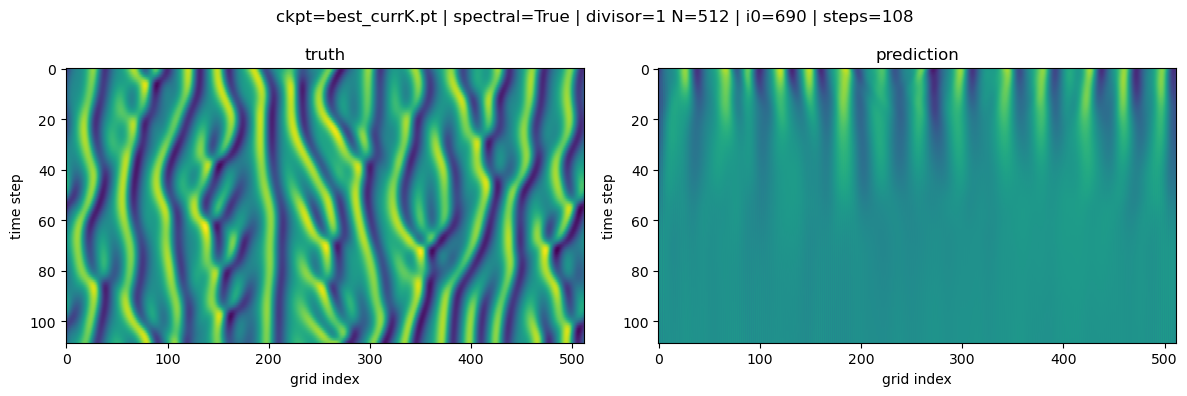

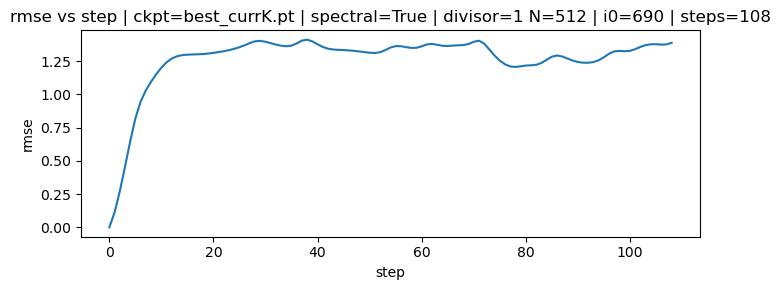

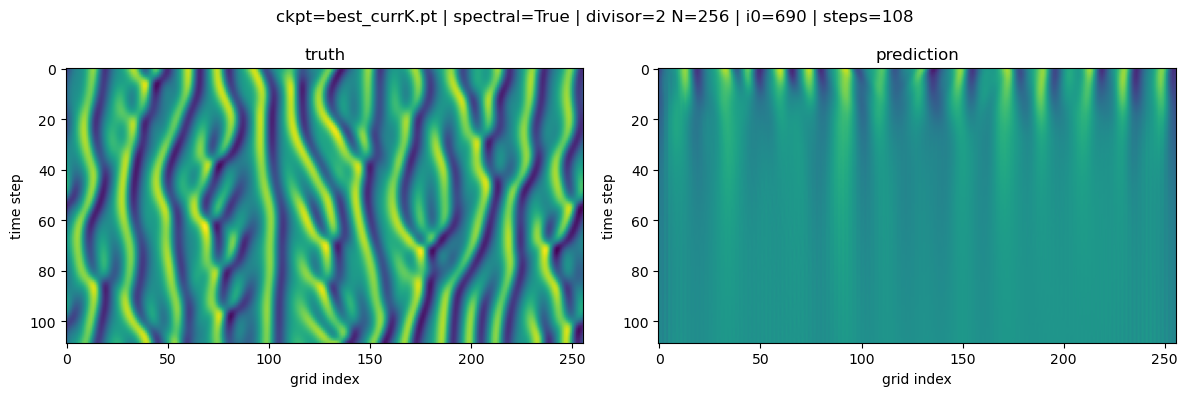

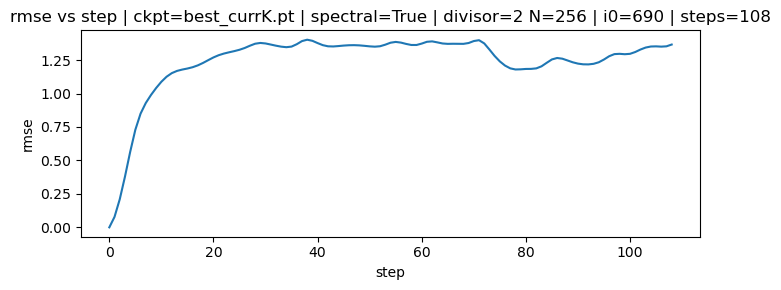

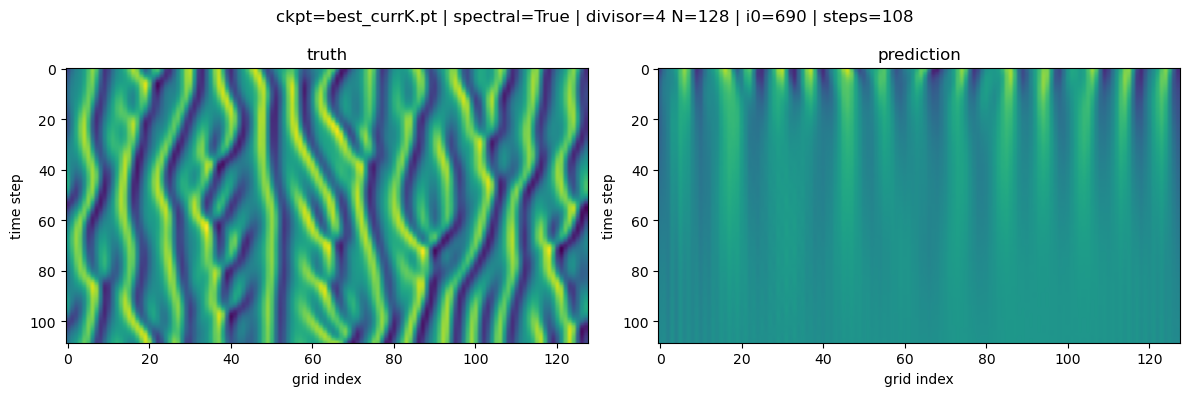

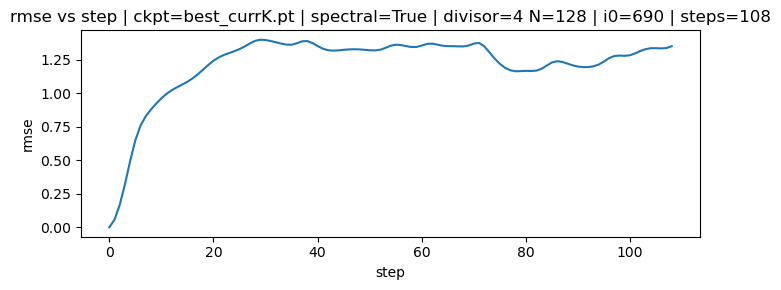

[done]


In [2]:
# ============================================
# Standalone: load ckpt + rebuild model + load data + one-step + rollout
# Supports both physical GridAgnostic1D and spectral-latent SpectralLatentStepper1D checkpoints
# Also uses chains_cache.npz (if present) to pick contiguous test segments for rollouts
# ============================================
import os, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from contextlib import nullcontext

# -----------------------
# user knobs
# -----------------------
DATA_DIR = Path("/scratch/pp3051/weather")
RUN_DIR  = Path("runs_grid_agnostic_closed_loop_exp10_stable")
DIVISORS = [1, 2, 4]

CHAIN_ID = 0
START_OFFSET = 10
ROLLOUT_STEPS = 200
ONE_STEP_SAMPLES = 4096
EVAL_BATCH = 512  # micro-batch for one-step to avoid GPU spikes

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# -----------------------

# -----------------------
# utilities
# -----------------------
def pick_best_ckpt(run_dir: Path) -> Path:
    for name in ["best_currK.pt", "best_one_step.pt", "last.pt"]:
        p = run_dir / name
        if p.exists():
            return p
    raise FileNotFoundError(f"No checkpoint found in {run_dir}")

def extract_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, dict):
        for k in ["model", "state_dict", "model_state_dict", "net", "network"]:
            if k in ckpt_obj and isinstance(ckpt_obj[k], dict):
                return ckpt_obj[k]
        if sum(torch.is_tensor(v) for v in ckpt_obj.values()) > 0:
            return ckpt_obj
    raise RuntimeError("Could not extract state_dict from checkpoint")

def strip_orig_mod(sd: dict) -> dict:
    if any(k.startswith("_orig_mod.") for k in sd.keys()):
        return {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
    return sd

def try_load_x_t(data_dir: Path):
    x = None; t = None
    for cand in ["ks_spatial_grid.npy", "x.npy", "ks_spatial_grid1.npy"]:
        p = data_dir/cand
        if p.exists():
            x = np.load(p).astype(np.float32)
            break
    for cand in ["ks_time.npy", "t.npy"]:
        p = data_dir/cand
        if p.exists():
            t = np.load(p).astype(np.float32)
            break
    return x, t

def infer_Lx_dt(x, t):
    if x is not None and len(x) >= 2:
        Lx = float((x[1] - x[0]) * len(x))
    else:
        Lx = 2.0 * math.pi
    dt = None
    if t is not None and len(t) >= 2:
        dt = float(t[1] - t[0])
    return Lx, dt

def downsample_mean(u_batch: np.ndarray, divisor: int) -> np.ndarray:
    if divisor == 1:
        return u_batch.astype(np.float32, copy=False)
    B, N0 = u_batch.shape
    assert N0 % divisor == 0
    N = N0 // divisor
    return u_batch.reshape(B, N, divisor).mean(axis=2).astype(np.float32)

def posenc_from_x(x: np.ndarray, freqs):
    x = x.astype(np.float32)
    x01 = (x - x.min()) / max(1e-12, (x.max() - x.min()))
    feats = []
    for f in freqs:
        ang = 2.0 * np.pi * float(f) * x01
        feats.append(np.sin(ang))
        feats.append(np.cos(ang))
    return np.stack(feats, axis=0).astype(np.float32)

def build_splits_from_chains(chains, T_train=0.70, T_val=0.15):
    tr, va, te = [], [], []
    for (s, e) in chains:
        s = int(s); e = int(e)
        L = e - s + 1
        a = int(math.floor(T_train * L))
        b = int(math.floor((T_train + T_val) * L))
        a = max(a, 4); b = max(b, a + 1)
        a = min(a, L - 2); b = min(b, L - 1)
        tr.append((s, s + a - 1))
        va.append((s + a, s + b - 1))
        te.append((s + b, e))
    return tr, va, te

@torch.no_grad()
def rmse(a, b):
    return torch.sqrt(((a - b) ** 2).mean()).item()

def _no_autocast():
    # safer for FFT paths; no-op in eval unless autocast got enabled externally
    if DEVICE == "cuda" and torch.is_autocast_enabled():
        try:
            return torch.amp.autocast("cuda", enabled=False)
        except Exception:
            return torch.cuda.amp.autocast(enabled=False)
    return nullcontext()

# -----------------------
# spectral helpers (only used if ckpt is spectral_latent)
# -----------------------
def posenc_from_mode(M: int, freqs):
    if M <= 1:
        x = np.zeros((1,), dtype=np.float32)
    else:
        x = np.linspace(0.0, 1.0, M, dtype=np.float32)
    feats = np.zeros((2 * len(freqs), M), dtype=np.float32)
    for i, f in enumerate(freqs):
        ang = 2 * math.pi * f * x
        feats[2*i]   = np.sin(ang).astype(np.float32)
        feats[2*i+1] = np.cos(ang).astype(np.float32)
    return feats

def rfft_trunc(u_n: torch.Tensor, M: int):
    # u_n: [B,1,N] float32 -> z: [B,M] complex
    z = torch.fft.rfft(u_n.squeeze(1), dim=-1)
    return z[:, :M]

def complex_to_ri(z: torch.Tensor):
    ri = torch.view_as_real(z)            # [B,M,2]
    return ri.permute(0, 2, 1).contiguous()  # [B,2,M]

def ri_to_complex(ri: torch.Tensor):
    return torch.complex(ri[:, 0, :], ri[:, 1, :])

def irfft_from_trunc(z_trunc: torch.Tensor, N: int, Nf: int):
    B, M = z_trunc.shape
    z_full = torch.zeros((B, Nf), device=z_trunc.device, dtype=z_trunc.dtype)
    z_full[:, :M] = z_trunc
    u = torch.fft.irfft(z_full, n=N, dim=-1)
    return u[:, None, :]

# -----------------------
# model definition (must match training)
# -----------------------
class BatchOrLayerNorm1d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        self.norm_type = norm_type
        if norm_type == "batch":
            self.bn = nn.BatchNorm1d(num_features)
            self.ln = None
        elif norm_type == "layer":
            self.ln = nn.LayerNorm(num_features)
            self.bn = None
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        if self.norm_type == "batch":
            return self.bn(x)
        x_perm = x.permute(0, 2, 1)
        x_norm = self.ln(x_perm)
        return x_norm.permute(0, 2, 1)

class ResidualDilated1D(nn.Module):
    def __init__(self, ch, d, norm_type, dropout_p):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act1  = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout(p=dropout_p)

        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1, dilation=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act2  = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout(p=dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class SpectralLatentStepper1D(nn.Module):
    def __init__(self, cin_latent, scalar_dim, hidden=96, norm_type="batch", dropout_p=0.1,
                 dz_clip_n=5.0, learned_damping=True, damp_init=2.0):
        super().__init__()
        self.dz_clip_n = float(dz_clip_n)
        self.learned_damping = bool(learned_damping)
        if self.learned_damping:
            self.log_damp = nn.Parameter(torch.tensor(
                float(math.log(math.expm1(damp_init) + 1e-6)), dtype=torch.float32
            ))
        else:
            self.register_buffer("log_damp", torch.tensor(0.0), persistent=False)

        self.stem = nn.Sequential(
            nn.Conv1d(cin_latent, hidden, 3, padding=1, bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )
        self.b1 = ResidualDilated1D(hidden, 1,  norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2,  norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4,  norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8,  norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Conv1d(hidden + 32, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 2, 1),
        )

    def damp(self, z: torch.Tensor, k2: torch.Tensor):
        if not self.learned_damping:
            return z
        c = torch.nn.functional.softplus(self.log_damp) + 1e-6
        a = torch.exp(-c * k2)  # [1,M]
        return z * a

    def forward(self, profiles_latent, scalars):
        h = self.stem(profiles_latent)
        h = self.b4(self.b3(self.b2(self.b1(h))))
        B, C, M = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 32, M)
        h = torch.cat([h, s], dim=1)
        dz = self.head(h)
        c = self.dz_clip_n
        if c > 0:
            dz = c * torch.tanh(dz / c)
        return dz

class GridAgnostic1D(nn.Module):
    def __init__(self, cin, scalar_dim, hidden=96, norm_type="batch", dropout_p=0.1, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv1d(cin, hidden, 3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )
        self.b1 = ResidualDilated1D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8, norm_type, dropout_p)
        self.b5 = ResidualDilated1D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.Conv1d(hidden + 32, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 1, 1),
        )

    def forward(self, profiles, scalars):
        h = self.stem(profiles)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))
        B, C, L = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 32, L)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)
        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out

# -----------------------
# load data
# -----------------------
needed = ["X_train.npy","y_train.npy","X_val.npy","y_val.npy","X_test.npy","y_test.npy"]
for f in needed:
    if not (DATA_DIR/f).exists():
        raise FileNotFoundError(f"Missing {f} in {DATA_DIR}")

Xtr = np.load(DATA_DIR/"X_train.npy").astype(np.float32)
Xva = np.load(DATA_DIR/"X_val.npy").astype(np.float32)
Xte = np.load(DATA_DIR/"X_test.npy").astype(np.float32)
X_all = np.concatenate([Xtr, Xva, Xte], axis=0).astype(np.float32, copy=False)

# chain-aware segments (optional)
te_segs = None
chains_cache = RUN_DIR / "chains_cache.npz"
if chains_cache.exists():
    obj = np.load(chains_cache, allow_pickle=True)
    chains = obj["chains"].tolist()
    _, _, te_segs = build_splits_from_chains(chains, T_train=0.70, T_val=0.15)
    print(f"[chains] loaded {chains_cache} | test_segs={len(te_segs)}")
else:
    print("[chains] chains_cache.npz not found; rollouts will use raw consecutive indices in X_all (may be invalid if not sequential).")

# -----------------------
# load ckpt and rebuild model
# -----------------------
ckpt_path = pick_best_ckpt(RUN_DIR)
print(f"[eval] loading checkpoint: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location=DEVICE)

sd = strip_orig_mod(extract_state_dict(ckpt))

# normalize norms keys to int if needed
norms = ckpt.get("norms", None)
if norms is None:
    raise RuntimeError("Checkpoint does not contain norms. Re-save ckpt with norms in it.")
norms = {int(k): v for k, v in norms.items()}

FREQS = tuple(ckpt.get("freqs", (1,2,4,8)))
include_dx = bool(ckpt.get("include_dx", True))
norm_type = ckpt.get("norm_type", "batch")
du_clip_n = float(ckpt.get("du_clip_n", 5.0))
evalK = int(ckpt.get("curr_K", 1))

Lx = float(ckpt.get("Lx", 0.0) or 0.0)
dt = ckpt.get("dt", None)

if Lx == 0.0:
    x_arr, t_arr = try_load_x_t(DATA_DIR)
    Lx, dt2 = infer_Lx_dt(x_arr, t_arr)
    if dt is None:
        dt = dt2

Sdim = int(ckpt.get("Sdim", 0) or 0)
if Sdim == 0:
    Sdim = 1 + (1 if dt is not None else 0) + (1 if include_dx else 0)

is_spec = bool(ckpt.get("spectral_latent", False))

if is_spec:
    Cin_latent = int(ckpt.get("Cin"))  # saved as latent Cin
    dz_clip_n = float(ckpt.get("dz_clip_n", 5.0))
    learned_damping = bool(ckpt.get("learned_damping", True))
    LATENT_M_MAX = int(ckpt.get("latent_m_max", 129))
    model = SpectralLatentStepper1D(
        cin_latent=Cin_latent,
        scalar_dim=Sdim,
        hidden=96,
        norm_type=norm_type,
        dropout_p=0.10,
        dz_clip_n=dz_clip_n,
        learned_damping=learned_damping,
        damp_init=2.0,
    ).to(DEVICE)
else:
    Cin = int(ckpt.get("Cin", 3 + 2 * len(FREQS)))
    model = GridAgnostic1D(
        cin=Cin,
        scalar_dim=Sdim,
        hidden=96,
        norm_type=norm_type,
        dropout_p=0.10,
        du_clip_n=du_clip_n,
    ).to(DEVICE)

missing, unexpected = model.load_state_dict(sd, strict=False)
print(f"[eval] loaded. missing={len(missing)} unexpected={len(unexpected)}")
model.eval()

print(f"[meta] spectral_latent={is_spec} freqs={FREQS} include_dx={include_dx} norm_type={norm_type} evalK={evalK}")
print(f"[meta] Lx={Lx} dt={dt}")

# build spectral cache per divisor if needed
spectral_cache = {}
if is_spec:
    for d in DIVISORS:
        N0 = X_all.shape[1]
        N = N0 // d
        Nf = N // 2 + 1
        M = int(min(LATENT_M_MAX, Nf))
        pe_k = torch.from_numpy(posenc_from_mode(M, FREQS)).to(DEVICE)  # [Cpe,M]
        if M <= 1:
            k2 = torch.zeros((1, M), dtype=torch.float32, device=DEVICE)
        else:
            m = torch.linspace(0.0, 1.0, M, device=DEVICE)
            k2 = (m * m)[None, :]
        spectral_cache[d] = {"N": N, "Nf": Nf, "M": M, "pe_k": pe_k, "k2": k2}
        print(f"[spectral] divisor={d} N={N} Nf={Nf} M={M}")

# -----------------------
# sampling indices for one-step (prefer test segments if available)
# -----------------------
def sample_valid_indices(n_samples: int, seed: int = 0):
    rng = np.random.default_rng(seed)
    if te_segs is None or len(te_segs) == 0:
        lo, hi = 2, X_all.shape[0] - 2
        return rng.integers(lo, hi + 1, size=min(n_samples, hi - lo + 1))

    # sample from within test segments, ensuring i+1 is within the same segment
    pool = []
    for (s, e) in te_segs:
        lo = s + 2
        hi = e - 1
        if hi >= lo:
            pool.append((lo, hi))
    if not pool:
        lo, hi = 2, X_all.shape[0] - 2
        return rng.integers(lo, hi + 1, size=min(n_samples, hi - lo + 1))

    # draw uniformly over segments by repeated sampling
    out = []
    while len(out) < n_samples:
        lo, hi = pool[rng.integers(0, len(pool))]
        out.append(int(rng.integers(lo, hi + 1)))
    return np.array(out[:n_samples], dtype=np.int64)

# -----------------------
# one-step test (sampled)
# -----------------------
@torch.inference_mode()
def one_step_rmse(divisor: int, n_samples: int = 4096, seed: int = 0):
    idx = sample_valid_indices(n_samples=n_samples, seed=seed)

    X0 = X_all[idx - 2]
    X1 = X_all[idx - 1]
    Xt = X_all[idx]
    Y1 = X_all[idx + 1]

    X0 = downsample_mean(X0, divisor)
    X1 = downsample_mean(X1, divisor)
    Xt = downsample_mean(Xt, divisor)
    Y1 = downsample_mean(Y1, divisor)

    N0 = X_all.shape[1]
    N = N0 // divisor
    dx = float(Lx) / float(N)

    scalars = [float(Lx)]
    if dt is not None:
        scalars.append(float(dt))
    if include_dx:
        scalars.append(float(dx))
    scalars = torch.tensor(scalars, dtype=torch.float32, device=DEVICE)[None, :]

    u_mean, u_std, du_mean, du_std = norms[divisor]

    total_se = 0.0
    total_n = 0

    for s in range(0, Xt.shape[0], EVAL_BATCH):
        e = min(Xt.shape[0], s + EVAL_BATCH)

        u_tm2 = torch.from_numpy(X0[s:e, None, :]).to(DEVICE)
        u_tm1 = torch.from_numpy(X1[s:e, None, :]).to(DEVICE)
        u_t   = torch.from_numpy(Xt[s:e, None, :]).to(DEVICE)
        y_tp1 = torch.from_numpy(Y1[s:e]).to(DEVICE)

        if not is_spec:
            x = (np.arange(N, dtype=np.float32) + 0.5) * dx
            pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)  # [1,Cpe,N]

            u_tm2_n = (u_tm2 - u_mean) / u_std
            u_tm1_n = (u_tm1 - u_mean) / u_std
            u_t_n   = (u_t   - u_mean) / u_std

            prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe.repeat(u_t.shape[0], 1, 1)], dim=1)
            du_n = model(prof, scalars.repeat(u_t.shape[0], 1))
            du   = du_n * du_std + du_mean
            y_hat = (u_t + du).squeeze(1)  # [B,N]
        else:
            cache = spectral_cache[divisor]
            M, Nf = int(cache["M"]), int(cache["Nf"])
            pe_k = cache["pe_k"][None, :, :].expand(u_t.shape[0], -1, -1)  # [B,Cpe,M]
            k2   = cache["k2"]                                            # [1,M]
            k2ch = k2[:, None, :].expand(u_t.shape[0], 1, M)

            with _no_autocast():
                z_tm2 = rfft_trunc(((u_tm2 - u_mean) / u_std).float(), M)
                z_tm1 = rfft_trunc(((u_tm1 - u_mean) / u_std).float(), M)
                z_tz  = rfft_trunc(((u_t   - u_mean) / u_std).float(), M)

            prof_lat = torch.cat(
                [complex_to_ri(z_tm2), complex_to_ri(z_tm1), complex_to_ri(z_tz), pe_k, k2ch],
                dim=1
            )
            dz_ri = model(prof_lat, scalars.repeat(u_t.shape[0], 1))
            dz = ri_to_complex(dz_ri)
            z_next = model.damp(z_tz, k2) + dz

            with _no_autocast():
                u_pred_n = irfft_from_trunc(z_next, N=N, Nf=Nf)
                y_hat = (u_pred_n * u_std + u_mean).squeeze(1)

        se = ((y_hat - y_tp1) ** 2).sum().item()
        total_se += se
        total_n += y_tp1.numel()

    return math.sqrt(total_se / max(1, total_n))

print("[test] one-step rmse")
for d in DIVISORS:
    r = one_step_rmse(d, n_samples=ONE_STEP_SAMPLES, seed=0)
    print(f"  divisor={d} N={X_all.shape[1]//d} rmse={r:.6f}")

# -----------------------
# rollout
# -----------------------
@torch.inference_mode()
def rollout_from_index(i0: int, steps: int, divisor: int):
    N0 = X_all.shape[1]
    N = N0 // divisor
    dx = float(Lx) / float(N)

    scalars = [float(Lx)]
    if dt is not None:
        scalars.append(float(dt))
    if include_dx:
        scalars.append(float(dx))
    scalars = torch.tensor(scalars, dtype=torch.float32, device=DEVICE)[None, :]

    u_mean, u_std, du_mean, du_std = norms[divisor]

    def down1(u1):
        u1 = u1.astype(np.float32, copy=False)[None, :]
        return downsample_mean(u1, divisor)[0]

    u_tm2 = torch.from_numpy(down1(X_all[i0 - 2])[None, None, :]).to(DEVICE)
    u_tm1 = torch.from_numpy(down1(X_all[i0 - 1])[None, None, :]).to(DEVICE)
    u_t   = torch.from_numpy(down1(X_all[i0      ])[None, None, :]).to(DEVICE)

    preds = [u_t.squeeze().cpu().numpy()]
    truth = [down1(X_all[i0]).copy()]

    if not is_spec:
        x = (np.arange(N, dtype=np.float32) + 0.5) * dx
        pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)

        for k in range(steps):
            u_tm2_n = (u_tm2 - u_mean) / u_std
            u_tm1_n = (u_tm1 - u_mean) / u_std
            u_t_n   = (u_t   - u_mean) / u_std
            prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

            du_n = model(prof, scalars)
            du   = du_n * du_std + du_mean
            u_next = u_t + du

            u_tm2, u_tm1, u_t = u_tm1, u_t, u_next
            preds.append(u_next.squeeze().cpu().numpy())
            truth.append(down1(X_all[i0 + k + 1]).copy())
    else:
        cache = spectral_cache[divisor]
        M, Nf = int(cache["M"]), int(cache["Nf"])
        pe_k = cache["pe_k"][None, :, :].expand(1, -1, -1)
        k2   = cache["k2"]
        k2ch = k2[:, None, :].expand(1, 1, M)

        with _no_autocast():
            z_tm2 = rfft_trunc(((u_tm2 - u_mean) / u_std).float(), M)
            z_tm1 = rfft_trunc(((u_tm1 - u_mean) / u_std).float(), M)
            z_tz  = rfft_trunc(((u_t   - u_mean) / u_std).float(), M)

        for k in range(steps):
            prof_lat = torch.cat(
                [complex_to_ri(z_tm2), complex_to_ri(z_tm1), complex_to_ri(z_tz), pe_k, k2ch],
                dim=1
            )
            dz_ri = model(prof_lat, scalars)
            dz = ri_to_complex(dz_ri)
            z_next = model.damp(z_tz, k2) + dz

            with _no_autocast():
                u_next_n = irfft_from_trunc(z_next, N=N, Nf=Nf)
                u_next = u_next_n * u_std + u_mean

            z_tm2, z_tm1, z_tz = z_tm1, z_tz, z_next
            preds.append(u_next.squeeze().cpu().numpy())
            truth.append(down1(X_all[i0 + k + 1]).copy())

    preds = np.stack(preds, axis=0)
    truth = np.stack(truth, axis=0)
    rmse_curve = np.sqrt(((preds - truth) ** 2).mean(axis=1))
    return preds, truth, rmse_curve

def plot_rollout(preds, truth, rmse_curve, title):
    vmin = min(truth.min(), preds.min())
    vmax = max(truth.max(), preds.max())

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(truth, aspect="auto", vmin=vmin, vmax=vmax)
    ax[0].set_title("truth")
    ax[1].imshow(preds, aspect="auto", vmin=vmin, vmax=vmax)
    ax[1].set_title("prediction")
    for a in ax:
        a.set_xlabel("grid index")
        a.set_ylabel("time step")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(rmse_curve)
    plt.title(f"rmse vs step | {title}")
    plt.xlabel("step")
    plt.ylabel("rmse")
    plt.tight_layout()
    plt.show()

print("[rollout] closed-loop")

# pick i0 from a contiguous test segment if chains exist; otherwise fallback to safe global index
if te_segs is not None and len(te_segs) > 0 and CHAIN_ID < len(te_segs):
    s, e = te_segs[CHAIN_ID]
    i0 = max(s + 2, s + START_OFFSET)
    steps_use = min(ROLLOUT_STEPS, max(10, (e - i0 - 1)))
    if i0 + steps_use + 1 > e:
        i0 = max(s + 2, e - steps_use - 1)
else:
    N_total = X_all.shape[0]
    i0 = max(2 + START_OFFSET, 2)
    max_steps = (N_total - 1) - i0
    steps_use = min(ROLLOUT_STEPS, max(10, max_steps - 1))
    if i0 + steps_use + 1 >= N_total:
        i0 = max(2, N_total - steps_use - 2)

for d in DIVISORS:
    preds, truth, rmse_curve = rollout_from_index(i0=i0, steps=steps_use, divisor=d)
    title = f"ckpt={ckpt_path.name} | spectral={is_spec} | divisor={d} N={truth.shape[1]} | i0={i0} | steps={steps_use}"
    plot_rollout(preds, truth, rmse_curve, title)

print("[done]")
